# FD001 Exploration (Phase 1.3)

Goal: *understand the data before writing the ETL* so every transform in `etl.py` is justified.
By the end we can answer the interview question **"which sensors did you drop and why?"** from evidence, not memory.

Exploration only — nothing here is imported by production code.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

COLS = ['unit_id', 'cycle'] + [f'setting_{i}' for i in (1, 2, 3)] + [f'sensor_{i}' for i in range(1, 22)]
SENSORS = [f'sensor_{i}' for i in range(1, 22)]

df = pd.read_csv('../data/raw/train_FD001.txt', sep=r'\s+', header=None, names=COLS)
print(df.shape, '|', df['unit_id'].nunique(), 'engines')
df.head()

(20631, 26) | 100 engines


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 1. The RUL label
RUL (Remaining Useful Life) = how many cycles until this engine fails. We don't have it as a column — we derive it.
For each engine, the last row in the *training* set **is** the failure point, so:

    RUL(row) = max_cycle_for_that_engine - current_cycle

The final row of every engine therefore has RUL = 0.

In [2]:
df['RUL'] = df.groupby('unit_id')['cycle'].transform('max') - df['cycle']
assert (df.groupby('unit_id')['RUL'].min() == 0).all()  # every engine ends at 0
df[['unit_id', 'cycle', 'RUL']].groupby('unit_id').tail(1).head()

,unit_id,cycle,RUL
191,1,192,0
478,2,287,0
657,3,179,0
846,4,189,0
1115,5,269,0


## 2. Engine lifetimes vary
If every engine failed at the same cycle we could ignore `unit_id`. They don't — so RUL must be computed per engine.
This is also why we split train/val **by engine**, not by row (Phase 1.5).

lifetime min/mean/max: 128 206 362


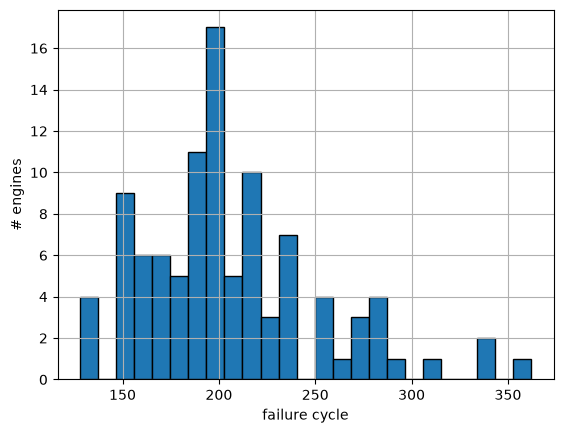

In [3]:
lifetimes = df.groupby('unit_id')['cycle'].max()
print('lifetime min/mean/max:', lifetimes.min(), round(lifetimes.mean()), lifetimes.max())
lifetimes.hist(bins=25, edgecolor='black'); plt.xlabel('failure cycle'); plt.ylabel('# engines'); plt.show()

## 3. Which sensors carry signal?
A sensor with ~zero standard deviation never moves — it's a constant, contributes nothing, and just adds noise/compute.
We find them **programmatically** (threshold on std) rather than hardcoding, so the same rule generalises to FD002–FD004.

In [4]:
stds = df[SENSORS].std().sort_values()
dead = stds[stds < 1e-6].index.tolist()
keep = [s for s in SENSORS if s not in dead]
print('DEAD (drop):', dead)
print('KEEP:', keep)
stds

DEAD (drop): ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5']
KEEP: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

## 4. Of the survivors, which actually trend toward failure?
Correlation of each kept sensor with RUL. High |corr| = strong monotonic drift as the engine ages — these will dominate feature importance later.

In [5]:
df[keep].corrwith(df['RUL']).abs().sort_values(ascending=False)

sensor_11    0.696228
sensor_4     0.678948
sensor_12    0.671983
sensor_7     0.657223
sensor_15    0.642667
sensor_21    0.635662
sensor_20    0.629428
sensor_2     0.606484
sensor_17    0.606154
sensor_3     0.584520
sensor_8     0.563968
sensor_13    0.562569
sensor_9     0.390102
sensor_14    0.306769
sensor_6     0.128348
dtype: float64

## 5. See it: trending vs flat sensors
Top row degrades steadily over an engine's life (real signal). Bottom row is flat (dead). This plot *is* the "why I dropped them" answer.

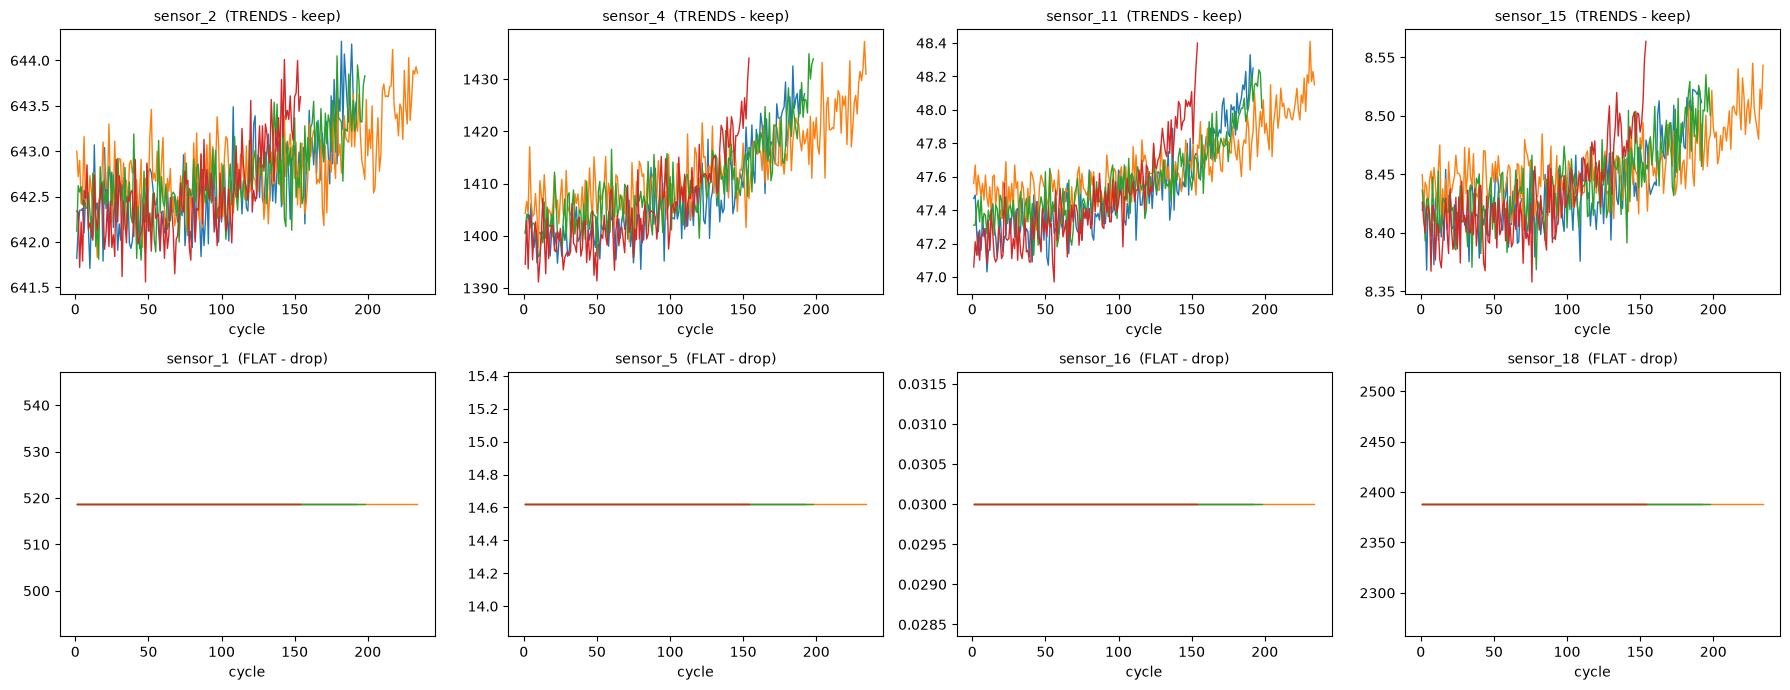

In [6]:
engines = [1, 20, 50, 90]
trend = ['sensor_2', 'sensor_4', 'sensor_11', 'sensor_15']
flat = ['sensor_1', 'sensor_5', 'sensor_16', 'sensor_18']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for row, group, tag in [(0, trend, 'TRENDS - keep'), (1, flat, 'FLAT - drop')]:
    for j, s in enumerate(group):
        ax = axes[row, j]
        for e in engines:
            sub = df[df.unit_id == e]
            ax.plot(sub.cycle, sub[s], lw=1)
        ax.set_title(f'{s}  ({tag})', fontsize=10)
        ax.set_xlabel('cycle')
fig.tight_layout(); plt.show()

## Takeaways for `etl.py`
1. **Label:** `RUL = max(cycle) - cycle` per engine; will be clipped at 125 in the ETL (degradation is flat early in life, so capping avoids the model chasing meaningless huge RULs).
2. **Drop 6 dead sensors** (std ≈ 0): `sensor_1, 5, 10, 16, 18, 19` — found by threshold, not hardcoded.
3. **Keep 15 sensors;** the strongest RUL signal is in `sensor_11, 4, 12, 7, 15` — expect these (and their rolling means) to top feature importance.
4. **Per-engine operations** (RUL, rolling windows, train/val split) — never mix engines.